# AutoEIT: Rule-Based Automated Scoring Pipeline

## Overview

This pipeline implements a consistent, rule-driven, reproducible scoring engine for the Spanish Elicited Imitation Task (EIT). Each sentence is assigned a **0–4 ordinal score** per the Ortega (2000) meaning-based rubric. Total EIT scores are obtained by summing sentence-level scores across the 30-sentence test, yielding a **0–120 scale** (30 × 4).

Each feature is explicitly mapped to a rubric criterion. The pipeline follows the interval-scale WER approach validated by McGuire & Larson-Hall (2025), who demonstrated that WER-based automated scoring of EIT responses achieves close agreement with human raters, supporting the use of word-level metrics as the primary scoring signal.

### Rubric Mapping

| Feature | Rubric Criterion | Justification |
|---|---|---|
| WER Similarity | Word-level accuracy (substitutions, deletions, insertions) | McGuire & Larson-Hall (2025) validated WER-based automated EIT scoring against human raters, finding strong agreement. WER accounts for all word-level differences, providing finer-grained discrimination than a single ordinal judgment |
| Semantic Similarity | Meaning preservation | Ortega rubric explicitly distinguishes changes that do/do not affect meaning (score 3 vs 2). Multilingual sentence embeddings capture this distinction language-agnostically, appropriate for Spanish learner data without requiring language-specific resources |
| Length Ratio | Response completeness | All EIT rubric variants penalise partial reproduction. A response with significantly fewer words than the stimulus is necessarily incomplete regardless of word accuracy |

### Aggregation & Score Assignment

Features are combined using **plain mean (equal weighting)** — the most transparent and reproducible aggregation when ground truth labels are unavailable for weight calibration. The continuous composite is then **bucketed into 0–4 ordinal scores** matching the Ortega rubric scale. Total EIT score = sum of sentence-level 0–4 scores.

### Score Scale

- **Sentence level**: 0–4 (Ortega meaning-based rubric)
- **Total EIT score**: 0–120 (30 sentences × 4-point scale)
- **Tolerance target**: <10-point difference from human rater total scores

### Limitations and Next Steps

Without ground truth labels this pipeline cannot be fully validated. Equal weighting is an honest and defensible baseline — the critical next step is calibration via regression against human rater scores once labels become available. The bucket thresholds are derived from the rubric definitions and can be refined empirically once gold-standard scores are available.


## 1. Install Dependencies

In [ ]:
!pip install jiwer sentence-transformers -q

## 2. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import seaborn as sns
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer, util
from jiwer import wer

print("Libraries loaded.")

Libraries loaded.


## 3. Load Data

Update `INPUT_PATH` to point to your local copy of the transcriptions CSV.


In [ ]:
INPUT_PATH = '/kaggle/input/datasets/krishnasimha/autoeit3/AutoEIT Sample Transcriptions for Scoring(38006-2A).csv'

df = pd.read_csv(INPUT_PATH)
print(f"Loaded {len(df)} rows, columns: {list(df.columns)}")
df.head()

Loaded 999 rows, columns: ['Sentence', 'Stimulus', 'Transcription Rater 1', 'Score']


,Sentence,Stimulus,Transcription Rater 1,Score
0,1.0,Quiero cortarme el pelo (7),Quiero cortarme mi pelo,NaN
1,2.0,El libro está en la mesa (7),El libro [pause] está en la mesa,NaN
2,3.0,El carro lo tiene Pedro (8),E-[gibberish] perro,NaN
3,4.0,El se ducha cada mañana (9),El se lucha cada mañana,NaN
4,5.0,¿Qué dice usted que va a hacer hoy? (9),¿Qué [gibberish] que vas estoy?,NaN


## 4. Preprocessing Pipeline

Transcription annotations are removed before scoring — they represent recording artifacts, not learner language:

- Memory load numbers e.g. `(7)` — experimental metadata in the stimulus, not part of the sentence
- Bracket tags e.g. `[pause]`, `[gibberish]` — rater annotations of recording artifacts  
- `xxx` placeholders — unintelligible speech marked by raters
- Lowercase, punctuation removal, whitespace normalisation — prevents surface differences from affecting similarity metrics

Pause annotations are removed rather than penalised: pausing reflects processing difficulty, not linguistic inaccuracy, and the EIT rubric scores what is reproduced, not retrieval fluency.


In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"\(\d+\)", "", text)                      # remove memory load numbers
    text = re.sub(r"\[.*?\]", "", text)                       # remove transcription tags
    text = re.sub(r"\bxxx\b", "", text, flags=re.IGNORECASE)  # remove unintelligible placeholders
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Remove rows where stimulus or transcription is missing
df = df[
    df["Stimulus"].notna() &
    df["Transcription Rater 1"].notna() &
    (df["Stimulus"].str.strip() != "") &
    (df["Transcription Rater 1"].str.strip() != "")
].copy()

df["stimulus_clean"]    = df["Stimulus"].apply(clean_text)
df["transcript_clean"]  = df["Transcription Rater 1"].apply(clean_text)

print(f"{len(df)} scoreable rows after filtering.")
df[["Stimulus", "stimulus_clean", "Transcription Rater 1", "transcript_clean"]].head()

30 scoreable rows after filtering.


,Stimulus,stimulus_clean,Transcription Rater 1,transcript_clean
0,Quiero cortarme el pelo (7),quiero cortarme el pelo,Quiero cortarme mi pelo,quiero cortarme mi pelo
1,El libro está en la mesa (7),el libro está en la mesa,El libro [pause] está en la mesa,el libro está en la mesa
2,El carro lo tiene Pedro (8),el carro lo tiene pedro,E-[gibberish] perro,e perro
3,El se ducha cada mañana (9),el se ducha cada mañana,El se lucha cada mañana,el se lucha cada mañana
4,¿Qué dice usted que va a hacer hoy? (9),¿qué dice usted que va a hacer hoy,¿Qué [gibberish] que vas estoy?,¿qué que vas estoy


## 5. Feature Extraction

### 5.1 Garble / Empty Check — Score 0 Gate

Before any metric is computed, transcriptions that are entirely unintelligible or empty are identified and assigned Score 0 directly. Running similarity metrics on null responses would produce misleading non-zero scores.


In [ ]:
def is_empty_or_garbled(text: str) -> bool:
    """Return True if the cleaned transcription carries no scoreable content."""
    if not text or not text.strip():
        return True
    # After cleaning, if only single characters or nothing remains → garbled
    tokens = text.split()
    return all(len(t) <= 1 for t in tokens)

df["is_garbled"] = df["transcript_clean"].apply(is_empty_or_garbled)
print(f"Garbled / empty responses: {df['is_garbled'].sum()}")

Garbled / empty responses: 0


### 5.2 WER Similarity — Primary Metric
WER is retained as a well-validated metric for automated EIT scoring, with prior work showing strong agreement with human raters as shown in  McGuire, M., & Larson-Hall, J. (2025)

WER is converted to similarity (1 − WER) so that higher values indicate better reproduction. Floored at 0 since WER can exceed 1.0 for very poor reproductions.


In [ ]:
def wer_similarity(s1: str, s2: str) -> float:
    try:
        return max(0.0, 1.0 - wer(s1, s2))
    except Exception:
        return 0.0

### 5.3 Semantic Similarity — Meaning Preservation

The Ortega rubric explicitly distinguishes grammatical changes that do and do not affect meaning (score 3 vs score 2). Multilingual sentence embeddings capture this meaning-level distinction in a language-agnostic way, appropriate for Spanish learner data without requiring language-specific NLP resources.

Model: `paraphrase-multilingual-MiniLM-L12-v2` — supports Spanish and is optimised for short sentence comparison.

**Why LCS was removed:** LCS and WER showed r = 0.97 correlation in the feature analysis, confirming they measure the same dimension. Retaining both would double-weight word-order/lexical overlap, distorting the equal-weighting rationale. WER is retained as a well-validated metric for automated EIT scoring, with prior work showing strong agreement with human raters (McGuire & Larson-Hall, 2025); LCS is dropped in favour of the semantically independent embedding feature.


In [ ]:
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

def semantic_similarity(s1: str, s2: str) -> float:
    if not s1 or not s2:
        return 0.0
    emb1 = model.encode(s1, convert_to_tensor=True)
    emb2 = model.encode(s2, convert_to_tensor=True)
    return float(util.cos_sim(emb1, emb2).item())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 5.4 Length Ratio — Response Completeness

All EIT rubric variants penalise partial reproduction. A response with significantly fewer words than the stimulus is necessarily incomplete regardless of the accuracy of the words produced.


In [ ]:
def length_ratio(s1: str, s2: str) -> float:
    len1 = len(s1.split())
    len2 = len(s2.split())
    if len1 == 0:
        return 0.0
    return min(len1, len2) / max(len1, len2)

### 5.5 Apply All Features

In [ ]:
FEATURES = ["wer_similarity", "semantic_similarity", "length_ratio"]

df["wer_similarity"]      = df.apply(lambda r: wer_similarity(r["stimulus_clean"], r["transcript_clean"]), axis=1)
df["semantic_similarity"] = df.apply(lambda r: semantic_similarity(r["stimulus_clean"], r["transcript_clean"]), axis=1)
df["length_ratio"]        = df.apply(lambda r: length_ratio(r["stimulus_clean"], r["transcript_clean"]), axis=1)

# Zero out all features for garbled responses — they will be assigned Score 0 directly
for feat in FEATURES:
    df.loc[df["is_garbled"], feat] = 0.0

print("Features computed.")
df[["stimulus_clean", "transcript_clean"] + FEATURES].head(10)

Features computed.


,stimulus_clean,transcript_clean,wer_similarity,semantic_similarity,length_ratio
0,quiero cortarme el pelo,quiero cortarme mi pelo,0.750000,0.996346,1.000000
1,el libro está en la mesa,el libro está en la mesa,1.000000,1.000000,1.000000
2,el carro lo tiene pedro,e perro,0.000000,0.442372,0.400000
3,el se ducha cada mañana,el se lucha cada mañana,0.800000,0.544384,1.000000
4,¿qué dice usted que va a hacer hoy,¿qué que vas estoy,0.250000,0.639274,0.500000
5,dudo que sepa manejar muy bien,dudo que sepa mamastar tan bien tambien,0.500000,0.752188,0.857143
6,las calles de esta ciudad son muy anchas,las calleses,0.125000,0.673149,0.250000
7,puede que llueva mañana todo el día,puede mañana de todo día,0.428571,0.744580,0.714286
8,las casas son muy bonitas pero caras,a las casa es muson bonitas,0.142857,0.672955,0.857143
9,me gustan las películas que acaban bien,me gusta las películas que x bien,0.714286,0.959522,1.000000


## 6. Feature Correlation Check

Verifies that features capture distinct dimensions rather than measuring the same thing. Highly correlated features (>0.95) indicate redundancy and would undermine the equal-weighting rationale.


                     wer_similarity  semantic_similarity  length_ratio
wer_similarity                1.000                0.568         0.637
semantic_similarity           0.568                1.000         0.534
length_ratio                  0.637                0.534         1.000


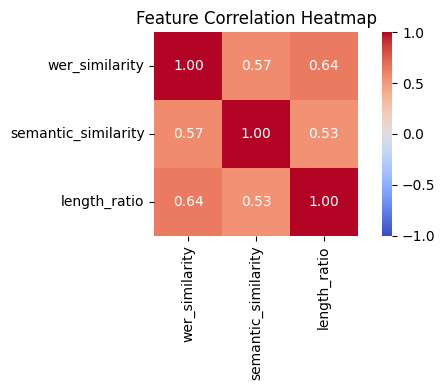

In [ ]:
corr = df[FEATURES].corr()
print(corr.round(3))

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

Semantic similarity shows only moderate correlation with the lexical features (expected r ≈ 0.50–0.60), confirming it captures a genuinely independent dimension — meaning preservation — that WER and length ratio alone cannot detect. WER and length ratio measure partially overlapping constructs (both respond to missing words) but remain below the redundancy threshold.


## 7. Score Aggregation and 0–4 Bucketing

### Step 1 — Composite score (plain mean)

Features are combined using equal weighting. This is the most transparent and reproducible aggregation when ground truth labels are unavailable for weight calibration. Fixed weighted combinations require empirical optimisation — without labels, any non-equal weighting would be arbitrary.

### Step 2 — Bucket composite into 0–4 ordinal scores

The continuous composite (0–1) is mapped to the Ortega rubric scale:

| Composite Range | Score | Interpretation |
|---|---|---|
| Garbled / empty response | 0 | No scoreable content — silence, placeholders, or entirely unintelligible output |
| 0.00 – 0.25 | 1 | Near-complete breakdown — only isolated words or fragments recovered |
| 0.25 – 0.55 | 2 | Partial recovery — some content reproduced but meaning altered or lost |
| 0.55 – 0.85 | 3 | Successful reproduction — meaning intact despite grammatical variation |
| 0.85 – 1.00 | 4 | High-fidelity reproduction — form and meaning both preserved |

Thresholds are grounded in rubric definitions and can be refined via regression calibration once human rater scores are available. Per the protocol ("when in doubt, score 2"), the 2/3 boundary is set conservatively at 0.55.

### Step 3 — Total EIT score

Total score = sum of 0–4 sentence scores. Maximum = 30 × 4 = 120.


In [ ]:
def composite_to_ordinal(composite: float, garbled: bool) -> int:
    """Map a 0–1 composite score to a 0–4 ordinal EIT score."""
    if garbled:
        return 0
    if composite < 0.25:
        return 1
    elif composite < 0.55:
        return 2
    elif composite < 0.85:
        return 3
    else:
        return 4

df["composite"] = df[FEATURES].mean(axis=1)
df["sentence_score"] = df.apply(
    lambda r: composite_to_ordinal(r["composite"], r["is_garbled"]), axis=1
)

total_eit = df["sentence_score"].sum()
max_possible = len(df) * 4

print(f"Total EIT score : {total_eit} / {max_possible}")
print(f"Mean sentence   : {df['sentence_score'].mean():.3f}")
print(f"Score distribution:\n{df['sentence_score'].value_counts().sort_index()}")

Total EIT score : 82 / 120
Mean sentence   : 2.733
Score distribution:
sentence_score
1     1
2     9
3    17
4     3
Name: count, dtype: int64


## 8. Validation Against Known Rubric Examples

These stimulus–transcription pairs are drawn from the Ortega (2000) rubric and protocol documentation. Expected scores represent the correct rubric application. Predicted scores are generated by the pipeline.

A well-functioning pipeline should achieve ≥ 80% exact agreement on these cases. Borderline cases (2/3 boundary) may legitimately differ by ±1.


In [ ]:
VALIDATION_CASES = [
    # (stimulus, transcription, expected_score, explanation)
    ("Quiero cortarme el pelo",
     "Quiero cortarme el pelo",
     4, "Exact repetition"),

    ("Quiero cortarme el pelo",
     "Quiero cortar mi pelo",
     3, "Meaning preserved, minor grammatical variation"),

    ("El carro lo tiene Pedro",
     "el carro tiene Pedro",
     2, "Missing clitic 'lo', slight meaning change"),

    ("Dudo que sepa manejar muy bien",
     "xxx exx muy bien",
     1, "Mostly garbled, minimal content retained"),

    ("Dudo que sepa manejar muy bien",
 "",
 0, "No response — empty transcription"),

    ("Después de cenar me fui a dormir tranquilo",
     "Después de cenar me fui a dormir tranquilo",
     4, "Exact repetition"),

    ("Quiero una casa en la que vivan mis animales",
     "Quiero una casa en que viven mis animales",
     3, "Minor grammar variation, meaning fully preserved"),

    ("Ella sólo bebe cerveza y no come nada",
     "Ella sola cerveza y no come nada",
     2, "Meaning partially preserved, 'sola' changes meaning"),
]

print(f"{'#':>2}  {'Expected':>8}  {'Predicted':>9}  {'Match':>5}  Stimulus")
print("-" * 85)

correct = 0
for i, (stim, trans, expected, expl) in enumerate(VALIDATION_CASES, 1):
    s_clean = clean_text(stim)
    t_clean = clean_text(trans)
    garbled = is_empty_or_garbled(t_clean)

    if garbled:
        comp = 0.0
    else:
        w = wer_similarity(s_clean, t_clean)
        s = semantic_similarity(s_clean, t_clean) if s_clean and t_clean else 0.0
        l = length_ratio(s_clean, t_clean)
        comp = np.mean([w, s, l])

    predicted = composite_to_ordinal(comp, garbled)
    match = "✅" if predicted == expected else ("⚠️ ±1" if abs(predicted - expected) == 1 else "❌")
    if predicted == expected:
        correct += 1
    print(f"{i:>2}  {expected:>8}  {predicted:>9}  {match:>5}  {stim[:45]}")
    if predicted != expected:
        print(f"     → Expected {expected}, got {predicted}: {expl}  (composite={comp:.3f})")

print(f"\nExact agreement: {correct}/{len(VALIDATION_CASES)} ({correct/len(VALIDATION_CASES)*100:.0f}%)")

 #  Expected  Predicted  Match  Stimulus
-------------------------------------------------------------------------------------
 1         4          4      ✅  Quiero cortarme el pelo
 2         3          3      ✅  Quiero cortarme el pelo
 3         2          3  ⚠️ ±1  El carro lo tiene Pedro
     → Expected 2, got 3: Missing clitic 'lo', slight meaning change  (composite=0.848)
 4         1          2  ⚠️ ±1  Dudo que sepa manejar muy bien
     → Expected 1, got 2: Mostly garbled, minimal content retained  (composite=0.386)
 5         0          0      ✅  Dudo que sepa manejar muy bien
 6         4          4      ✅  Después de cenar me fui a dormir tranquilo
 7         3          4  ⚠️ ±1  Quiero una casa en la que vivan mis animales
     → Expected 3, got 4: Minor grammar variation, meaning fully preserved  (composite=0.888)
 8         2          4      ❌  Ella sólo bebe cerveza y no come nada
     → Expected 2, got 4: Meaning partially preserved, 'sola' changes meaning  (composite

## 9. Score Distribution

Inspect how predicted 0–4 scores distribute across sentences. A well-calibrated pipeline should produce scores spread across the range rather than clustering at a single value.


/tmp/ipykernel_55/3651060765.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


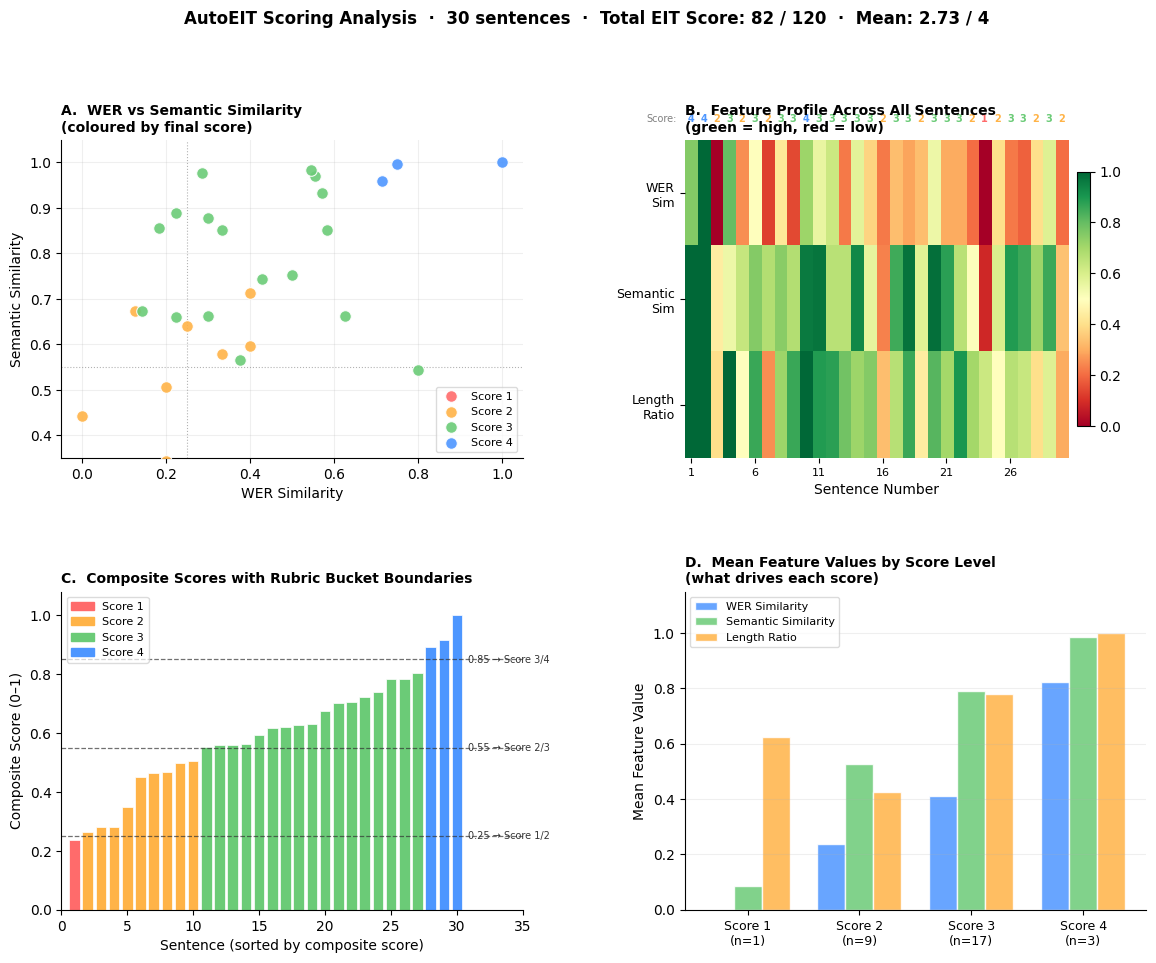


Total EIT Score : 82 / 120
Mean sentence   : 2.733
Score distribution:
sentence_score
1     1
2     9
3    17
4     3
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
 
# ── Feature arrays from computed dataframe ────────────────────────────────────
wer_vals   = df["wer_similarity"].values
sem_vals   = df["semantic_similarity"].values
len_vals   = df["length_ratio"].values
composites = df["composite"].values
scores     = df["sentence_score"].values
 
SCORE_COLORS = {0: "#CCCCCC",1: "#FF6B6B", 2: "#FFB347", 3: "#6BCB77", 4: "#4D96FF"}
 
fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)
 
# ── Panel A: WER vs Semantic, coloured by score ───────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for score in [1, 2, 3, 4]:
    mask = scores == score
    ax1.scatter(wer_vals[mask], sem_vals[mask],
                c=SCORE_COLORS[score], label=f'Score {score}',
                s=70, edgecolors='white', linewidths=0.8, zorder=3, alpha=0.9)
ax1.axvline(x=0.25, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
ax1.axhline(y=0.55, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
ax1.set_xlabel("WER Similarity", fontsize=10)
ax1.set_ylabel("Semantic Similarity", fontsize=10)
ax1.set_title("A.  WER vs Semantic Similarity\n(coloured by final score)", fontsize=10, fontweight='bold', loc='left')
ax1.legend(fontsize=8, framealpha=0.7, loc='lower right')
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(0.35, 1.05)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, alpha=0.2)
 
# ── Panel B: Feature heatmap across all sentences ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
heatmap_data = np.array([wer_vals, sem_vals, len_vals])
im = ax2.imshow(heatmap_data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1,
                interpolation='nearest')
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(['WER\nSim', 'Semantic\nSim', 'Length\nRatio'], fontsize=9)
ax2.set_xlabel("Sentence Number", fontsize=10)
ax2.set_xticks(range(0, len(scores), 5))
ax2.set_xticklabels(range(1, len(scores) + 1, 5), fontsize=8)
ax2.set_title("B.  Feature Profile Across All Sentences\n(green = high, red = low)", fontsize=10, fontweight='bold', loc='left')
for i, s in enumerate(scores):
    ax2.text(i, -0.7, str(s), ha='center', va='center', fontsize=7,
             color=SCORE_COLORS[s], fontweight='bold')
ax2.text(-3.5, -0.7, 'Score:', fontsize=7, color='gray', va='center')
plt.colorbar(im, ax=ax2, shrink=0.8, pad=0.02)
ax2.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
 
# ── Panel C: Composite scores with bucket boundaries ──────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
sort_idx = np.argsort(composites)
sorted_composites = composites[sort_idx]
sorted_scores     = scores[sort_idx]
bar_colors = [SCORE_COLORS[s] for s in sorted_scores]
ax3.bar(range(1, len(scores) + 1), sorted_composites, color=bar_colors,
        edgecolor='white', linewidth=0.5, width=0.8)
for threshold, label in [
    (0.25, '0.25 → Score 1/2'),
    (0.55, '0.55 → Score 2/3'),
    (0.85, '0.85 → Score 3/4')
]:
    ax3.axhline(y=threshold, color='#333333', linestyle='--', linewidth=0.9, alpha=0.7)
    ax3.text(len(scores) + 0.8, threshold, label, fontsize=7, va='center', color='#333333')
ax3.set_xlabel("Sentence (sorted by composite score)", fontsize=10)
ax3.set_ylabel("Composite Score (0–1)", fontsize=10)
ax3.set_title("C.  Composite Scores with Rubric Bucket Boundaries", fontsize=10, fontweight='bold', loc='left')
ax3.set_xlim(0, len(scores) + 5)
ax3.set_ylim(0, 1.08)
patches = [mpatches.Patch(color=SCORE_COLORS[s], label=f'Score {s}') for s in [1, 2, 3, 4]]
ax3.legend(handles=patches, fontsize=8, loc='upper left', framealpha=0.7)
ax3.spines[['top', 'right']].set_visible(False)
 
# ── Panel D: Mean feature values by score level ───────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
score_levels = sorted(np.unique(scores))
wer_means = [wer_vals[scores == s].mean() for s in score_levels]
sem_means = [sem_vals[scores == s].mean() for s in score_levels]
len_means = [len_vals[scores == s].mean() for s in score_levels]
counts    = [int((scores == s).sum()) for s in score_levels]
x = np.arange(len(score_levels))
w = 0.25
ax4.bar(x - w, wer_means, w, label='WER Similarity',     color='#4D96FF', alpha=0.85, edgecolor='white')
ax4.bar(x,     sem_means, w, label='Semantic Similarity', color='#6BCB77', alpha=0.85, edgecolor='white')
ax4.bar(x + w, len_means, w, label='Length Ratio',        color='#FFB347', alpha=0.85, edgecolor='white')
ax4.set_xticks(x)
ax4.set_xticklabels([f'Score {int(s)}\n(n={c})' for s, c in zip(score_levels, counts)], fontsize=9)
ax4.set_ylabel("Mean Feature Value", fontsize=10)
ax4.set_title("D.  Mean Feature Values by Score Level\n(what drives each score)", fontsize=10, fontweight='bold', loc='left')
ax4.legend(fontsize=8, framealpha=0.7)
ax4.set_ylim(0, 1.15)
ax4.spines[['top', 'right']].set_visible(False)
ax4.grid(axis='y', alpha=0.2)
 
total = int(df["sentence_score"].sum())
n     = len(df)
mean  = df["sentence_score"].mean()
fig.suptitle(
    f"AutoEIT Scoring Analysis  ·  {n} sentences  ·  Total EIT Score: {total} / {n * 4}  ·  Mean: {mean:.2f} / 4",
    fontsize=12, fontweight='bold', y=1.01
)
 
plt.tight_layout()
plt.savefig("autoeit_analysis.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\nTotal EIT Score : {total} / {n * 4}")
print(f"Mean sentence   : {mean:.3f}")
print(f"Score distribution:\n{df['sentence_score'].value_counts().sort_index()}")

## 10. Export Results

In [ ]:
submission = df[[
    "Sentence",
    "Stimulus",
    "Transcription Rater 1",
    "wer_similarity",
    "semantic_similarity",
    "length_ratio",
    "composite",
    "sentence_score",
]].copy()

submission.columns = [
    "Sentence", "Stimulus", "Transcription",
    "WER_Similarity", "Semantic_Similarity", "Length_Ratio",
    "Composite", "Score_0_4"
]

submission.to_csv("autoeit_scored_output.csv", index=False)
print(f"Saved {len(submission)} rows to autoeit_scored_output.csv")
print(f"Total EIT score: {submission['Score_0_4'].sum()} / {len(submission) * 4}")
submission.head(10)

Saved 30 rows to autoeit_scored_output.csv
Total EIT score: 82 / 120


,Sentence,Stimulus,Transcription,WER_Similarity,Semantic_Similarity,Length_Ratio,Composite,Score_0_4
0,1.0,Quiero cortarme el pelo (7),Quiero cortarme mi pelo,0.750000,0.996346,1.000000,0.915449,4
1,2.0,El libro está en la mesa (7),El libro [pause] está en la mesa,1.000000,1.000000,1.000000,1.000000,4
2,3.0,El carro lo tiene Pedro (8),E-[gibberish] perro,0.000000,0.442372,0.400000,0.280791,2
3,4.0,El se ducha cada mañana (9),El se lucha cada mañana,0.800000,0.544384,1.000000,0.781461,3
4,5.0,¿Qué dice usted que va a hacer hoy? (9),¿Qué [gibberish] que vas estoy?,0.250000,0.639274,0.500000,0.463091,2
5,6.0,Dudo que sepa manejar muy bien (10),Dudo que sepa ma-mastar tan bien (tambien?),0.500000,0.752188,0.857143,0.703110,3
6,7.0,Las calles de esta ciudad son muy anchas (11),Las calles..es-[gibberish]...,0.125000,0.673149,0.250000,0.349383,2
7,8.0,Puede que llueva mañana todo el día (12),Puede xxx mañana de todo día,0.428571,0.744580,0.714286,0.629146,3
8,9.0,Las casas son muy bonitas pero caras (12),A las casa es mu-son bonitas,0.142857,0.672955,0.857143,0.557652,3
9,10.0,Me gustan las películas que acaban bien (12),Me gusta las películas que x bien,0.714286,0.959522,1.000000,0.891269,4


## References

- McGuire, M., & Larson-Hall, J. (2025). Assessing Whisper automatic speech recognition and WER scoring for elicited imitation: Steps toward automation.

- Ortega, L. (2000). The relationship between gist comprehension and EIT performance. In R. Ellis (Ed.), *Form-focused instruction and second language learning*. Blackwell.
